Method 1
-

In [1]:
import math as maths

import cartopy.crs as ccrs
import intake
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import easygems.healpix as egh

from easygems.healpix import attach_coords

/home/users/mmuetz/miniforge3/envs/hackathon_env/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
import warnings

# Suppress specific FutureWarnings matching the message pattern when using cat[...].to_dask()
warnings.filterwarnings(
    "ignore",
    message=".*The return type of `Dataset.dims` will be changed.*",
    category=FutureWarning,
)

In [3]:
current_location = "online"
cat = intake.open_catalog("https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml")[current_location]

In [4]:
list (cat)

['CERES_EBAF',
 'ERA5',
 'IR_IMERG',
 'JRA3Q',
 'MERRA2',
 'casesm2_10km_nocumulus',
 'icon_d3hp003',
 'icon_d3hp003aug',
 'icon_d3hp003feb',
 'icon_ngc4008',
 'ifs_tco3999-ng5_deepoff',
 'ifs_tco3999-ng5_rcbmf',
 'ifs_tco3999-ng5_rcbmf_cf',
 'nicam_220m_test',
 'nicam_gl11',
 'scream-dkrz',
 'tracking-d3hp003',
 'um_Africa_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_CTC_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_SAmer_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_SEA_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_glm_n1280_CoMA9_TBv1p2',
 'um_glm_n1280_GAL9',
 'um_glm_n2560_RAL3p3']

In [5]:
ds_glo = cat["um_glm_n1280_GAL9"](zoom=7).to_dask().pipe(attach_coords)
ds_lam = cat["um_Africa_km4p4_RAL3P3_n1280_GAL9_nest"](zoom=7).to_dask().pipe(attach_coords)

In [6]:
icells_glo = np.where((ds_glo.lat >= -20.) & (ds_glo.lat <= 20.) & (ds_glo.lon >= 0.) & (ds_glo.lon <= 30.))[0]
icells_lam = np.where((ds_lam.lat >= -20.) & (ds_lam.lat <= 20.) & (ds_lam.lon >= 0.) & (ds_lam.lon <= 30.))[0]

In [7]:
# check where cell indices match
icells_inters = icells_glo[icells_glo == icells_lam]
icells_inters

array([2186, 2208, 2209, 2210, 2211, 2214, 2216, 2217, 2218, 2219, 2220,
       2221, 2222, 2223, 2234, 2560, 2561, 2562, 2563, 2564, 2565, 2566,
       2567, 2568, 2569, 2570, 2571, 2572, 2573, 2574, 2575, 2576, 2577,
       2578, 2579, 2582, 2584, 2585, 2586, 2587, 2588, 2589, 2590, 2591,
       2592, 2593, 2594, 2595, 2596, 2597, 2598, 2599, 2600, 2601, 2602,
       2603, 2604, 2605, 2606, 2607, 2608, 2609, 2610, 2611, 2612, 2613,
       2614, 2615, 2616, 2617, 2618, 2619, 2620, 2621, 2622, 2623, 2634,
       2656, 2657, 2658, 2659, 2662, 2664, 2665, 2666, 2667, 2668, 2688,
       2689, 2690, 2691, 2692, 2693, 2694, 2695, 2696, 2697, 2698, 2699,
       2700, 2701, 2702, 2703, 2704, 2705, 2706, 2707, 2708, 2709, 2710,
       2711, 2712, 2713, 2714, 2715, 2716, 2720, 2721, 2722, 2723, 2724,
       2725, 2726, 2727, 2728, 2729, 2730, 2731, 2732, 2736, 2752, 8192])

In [8]:
ds_glo_ = ds_glo.isel(cell=icells_glo)
ds_lam_ = ds_lam.isel(cell=icells_lam)

array(297.32217, dtype=float32)

<Figure size 640x480 with 0 Axes>

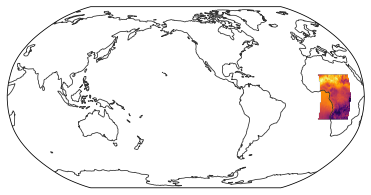

In [9]:
egh.healpix_show(ds_glo_["tas"].sel(time="2020-05-10T00:00:00"), cmap="inferno", dpi=72)
ds_glo_["tas"].sel(time="2020-05-10T00:00:00").mean().values

array(297.46542, dtype=float32)

<Figure size 640x480 with 0 Axes>

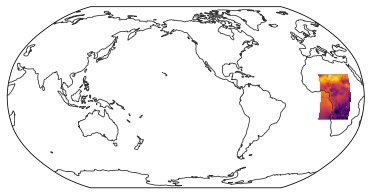

In [10]:
egh.healpix_show(ds_lam_["tas"].sel(time="2020-05-10T00:00:00"), cmap="inferno", dpi=72)
ds_lam_["tas"].sel(time="2020-05-10T00:00:00").mean().values

Method 2
-
Using the global indexing function

In [12]:
import healpy

In [13]:
def get_nn_lon_lat_index(zoom=8, lat_range=(-30., 30.), lon_range=(-180., 180.)):
    """for subsetting HEALPix ICON out onto regular lat/lon grid"""
    lat_min = lat_range[0]
    lat_max = lat_range[1]
    lon_min = lon_range[0]
    lon_max = lon_range[1]
    lat_diff = lat_max - lat_min
    lon_diff = lon_max - lon_min
    if zoom == 6:  # ~100km -> 1 deg. = 1 pixel
        n = 1
    elif zoom == 7:  # ~30km -> 1 deg. = 3 pixel
        n = 3
    elif zoom == 8:  # ~20km -> 1 deg. = 5 pixel
        n = 5
    elif zoom == 9:  # ~10km -> 1 deg. = 10 pixel
        n = 10
    elif zoom == 10:  # ~5km -> 1 deg. = 20 pixel
        n = 20
    else:
        print("Don't know what to do with %s"%zoom)

    lats = np.linspace(lat_min, lat_max, int(lat_diff*n))
    lons = np.linspace(lon_min, lon_max, int(lon_diff*n))

    lons2, lats2 = np.meshgrid(lons, lats)
    nside = 2**zoom

    out = xr.DataArray(healpy.ang2pix(nside, lons2, lats2, nest=True, lonlat=True),
        coords=[("lat", lats), ("lon", lons)],
    )

    return out

In [14]:
idx = get_nn_lon_lat_index(zoom=7, lat_range=(-10., 10.), lon_range=(0., 30.))

In [15]:
ds_glo2 = cat["um_glm_n1280_GAL9"](zoom=7).to_dask()
ds_lam2 = cat["um_Africa_km4p4_RAL3P3_n1280_GAL9_nest"](zoom=7).to_dask()

In [16]:
var_glo2_ = ds_glo2['tas'].isel(cell=idx)

In [17]:
# This will yield an error if the sampling domain is extended 
var_lam2_ = ds_lam2['tas'].isel(cell=idx)

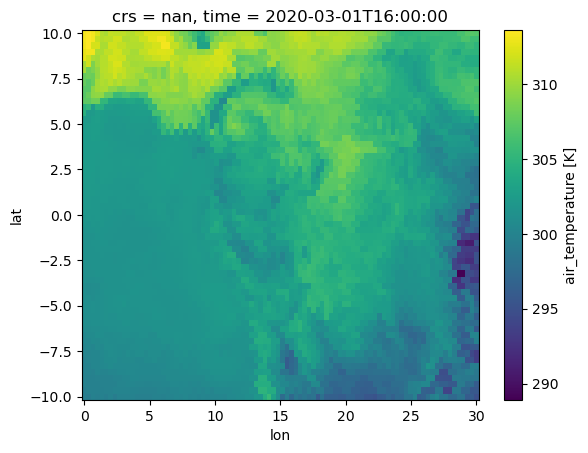

In [18]:
var_glo2_.isel(time=1000).plot()

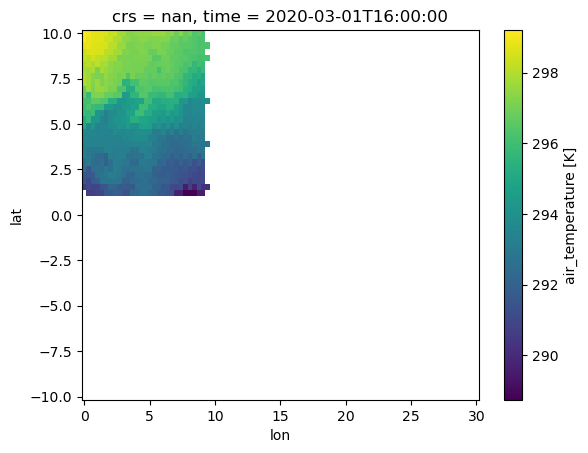

In [19]:
var_lam2_.isel(time=1000).plot()